In [18]:
import pandas as pd

In [19]:
import os

# Check where your CSV file is located
# First, list files in your current directory to find the CSV
print("Files in current directory:")
print(os.listdir('.'))

Files in current directory:
['.ipynb_checkpoints', 'All Lending Club loan data', 'All Lending Club loan data.zip', 'anaconda_projects', 'Untitled.ipynb']


In [5]:
folder_path = 'All Lending Club loan data'
files_in_folder = os.listdir(folder_path)

In [6]:
print("Files in the Lending Club folder:")
for file in files_in_folder:
    print(f"  - {file}")

Files in the Lending Club folder:
  - accepted_2007_to_2018q4.csv
  - accepted_2007_to_2018Q4.csv.gz
  - rejected_2007_to_2018q4.csv
  - rejected_2007_to_2018Q4.csv.gz


In [7]:
df = pd.read_csv('All Lending Club loan data/accepted_2007_to_2018Q4.csv/accepted_2007_to_2018Q4.csv',low_memory=False)
print("✅ Dataset loaded successfully!")
print(f"\nDataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nFirst few column names:")
print(df.columns.tolist()[:20])  # Show first 20 columns

✅ Dataset loaded successfully!

Dataset Shape: 2,260,701 rows × 151 columns

First few column names:
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc']


In [8]:
print("=" * 70)
print("DATASET INFO")
print("=" * 70)
print(f"Total Rows: {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")
print(f"\nData Types:")
print(df.dtypes.value_counts())



DATASET INFO
Total Rows: 2,260,701
Total Columns: 151

Data Types:
float64    113
object      38
Name: count, dtype: int64


In [9]:
print("\n" + "=" * 70)
print("KEY COLUMNS FOR ANALYSIS")
print("=" * 70)

# Check key columns we'll use
key_cols = ['loan_amnt', 'funded_amnt', 'int_rate', 'annual_inc', 'grade', 'loan_status', 'dti', 'fico_range_high']
for col in key_cols:
    if col in df.columns:
        print(f"\n✅ {col}: exists")
    else:
        print(f"\n❌ {col}: NOT FOUND")


KEY COLUMNS FOR ANALYSIS

✅ loan_amnt: exists

✅ funded_amnt: exists

✅ int_rate: exists

✅ annual_inc: exists

✅ grade: exists

✅ loan_status: exists

✅ dti: exists

✅ fico_range_high: exists


In [10]:
print("\n" + "=" * 70)
print("LOAN STATUS VALUES (What we'll analyze)")
print("=" * 70)
print(df['loan_status'].value_counts())


LOAN STATUS VALUES (What we'll analyze)
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


KEY INSIGHT:

DEFAULT RATE = Charged Off + Default = 268,599 / 2,260,701 = ~11.9%

This means roughly 1 in 8 loans default.

In [11]:
# Create a binary default column
# Charged Off or Default = 1 (defaulted)
# Everything else = 0 (paid or current)

df['is_default'] = df['loan_status'].isin(['Charged Off', 'Default']).astype(int)
print("=" * 70)
print("DEFAULT RATE CALCULATION")
print("=" * 70)

total_loans = len(df)
default_count = df['is_default'].sum()
default_rate = (default_count / total_loans) * 100
print(f"Total Loans: {total_loans:,}")
print(f"Defaulted Loans: {default_count:,}")
print(f"Default Rate: {default_rate:.2f}%")


DEFAULT RATE CALCULATION
Total Loans: 2,260,701
Defaulted Loans: 268,599
Default Rate: 11.88%


In [12]:
print("\n" + "=" * 70)
print("BASIC STATISTICS")
print("=" * 70)

print(f"\nLoan Amount:")
print(f"  Average: ${df['loan_amnt'].mean():,.2f}")
print(f"  Min: ${df['loan_amnt'].min():,.2f}")
print(f"  Max: ${df['loan_amnt'].max():,.2f}")

print(f"\nInterest Rate:")
print(f"  Average: {df['int_rate'].mean():.2f}%")
print(f"  Min: {df['int_rate'].min():.2f}%")
print(f"  Max: {df['int_rate'].max():.2f}%")

print(f"\nAnnual Income:")
print(f"  Average: ${df['annual_inc'].mean():,.2f}")
print(f"  Median: ${df['annual_inc'].median():,.2f}")

print(f"\nCredit Grade Distribution:")
print(df['grade'].value_counts().sort_index())


BASIC STATISTICS

Loan Amount:
  Average: $15,046.93
  Min: $500.00
  Max: $40,000.00

Interest Rate:
  Average: 13.09%
  Min: 5.31%
  Max: 30.99%

Annual Income:
  Average: $77,992.43
  Median: $65,000.00

Credit Grade Distribution:
grade
A    433027
B    663557
C    650053
D    324424
E    135639
F     41800
G     12168
Name: count, dtype: int64


In [13]:
print("=" * 70)
print("DEFAULT RATE BY CREDIT GRADE")
print("=" * 70)

# Group by grade and calculate default rate
grade_analysis = df.groupby('grade').agg({
    'is_default': ['count', 'sum', 'mean']
}).round(4)

grade_analysis.columns = ['Total_Loans', 'Defaults', 'Default_Rate']
grade_analysis['Default_Rate_Pct'] = grade_analysis['Default_Rate'] * 100

print(grade_analysis[['Total_Loans', 'Defaults', 'Default_Rate_Pct']])

print("\n" + "=" * 70)
print("KEY INSIGHT")
print("=" * 70)
print("Grade A (best credit) has lowest default rate")
print("Grade G (worst credit) has highest default rate")
print("\nThis shows: CREDIT SCORE PREDICTS DEFAULT RISK!")

DEFAULT RATE BY CREDIT GRADE
       Total_Loans  Defaults  Default_Rate_Pct
grade                                         
A           433027     14206              3.28
B           663557     52576              7.92
C           650053     85657             13.18
D           324424     61067             18.82
E           135639     36041             26.57
F            41800     14492             34.67
G            12168      4560             37.48

KEY INSIGHT
Grade A (best credit) has lowest default rate
Grade G (worst credit) has highest default rate

This shows: CREDIT SCORE PREDICTS DEFAULT RISK!


KEY FINDING:

Default rate goes from 3.28% (Grade A) to 37.48% (Grade G)

That's an 11X INCREASE in risk!

In [14]:
print("=" * 70)
print("DEFAULT RATE BY INTEREST RATE BRACKET")
print("=" * 70)

# Create interest rate brackets
df['int_rate_bracket'] = pd.cut(df['int_rate'], 
                                 bins=[0, 8, 12, 16, 20, 100],
                                 labels=['Low (0-8%)', 'Medium (8-12%)', 'High (12-16%)', 'Very High (16-20%)', 'Extreme (20%+)'])

int_rate_analysis = df.groupby('int_rate_bracket', observed=True).agg({
    'is_default': ['count', 'sum', 'mean']
}).round(4)

int_rate_analysis.columns = ['Total_Loans', 'Defaults', 'Default_Rate']
int_rate_analysis['Default_Rate_Pct'] = int_rate_analysis['Default_Rate'] * 100

print(int_rate_analysis[['Total_Loans', 'Defaults', 'Default_Rate_Pct']])

print("\n" + "=" * 70)
print("KEY INSIGHT")
print("=" * 70)
print("Higher interest rates = Higher default risk")
print("Lenders charge higher rates to compensate for risk")
print("BUT: Even high rates don't fully offset the default losses!")

DEFAULT RATE BY INTEREST RATE BRACKET
                    Total_Loans  Defaults  Default_Rate_Pct
int_rate_bracket                                           
Low (0-8%)               382213     12141              3.18
Medium (8-12%)           664704     51006              7.67
High (12-16%)            661910     90533             13.68
Very High (16-20%)       374032     71213             19.04
Extreme (20%+)           177809     43706             24.58

KEY INSIGHT
Higher interest rates = Higher default risk
Lenders charge higher rates to compensate for risk
BUT: Even high rates don't fully offset the default losses!


KEY INSIGHT:

Default rate increases from 3.18% → 24.58% as interest rates rise.

In [15]:
print("=" * 70)
print("DEFAULT RATE BY ANNUAL INCOME BRACKET")
print("=" * 70)

# Create income brackets
df['income_bracket'] = pd.cut(df['annual_inc'], 
                               bins=[0, 30000, 50000, 75000, 100000, 150000, 1000000],
                               labels=['<$30K', '$30-50K', '$50-75K', '$75-100K', '$100-150K', '$150K+'])

income_analysis = df.groupby('income_bracket', observed=True).agg({
    'is_default': ['count', 'sum', 'mean']
}).round(4)

income_analysis.columns = ['Total_Loans', 'Defaults', 'Default_Rate']
income_analysis['Default_Rate_Pct'] = income_analysis['Default_Rate'] * 100

print(income_analysis[['Total_Loans', 'Defaults', 'Default_Rate_Pct']])

print("\n" + "=" * 70)
print("KEY INSIGHT")
print("=" * 70)
print("Lower income borrowers = Higher default risk")
print("This makes sense: less money = harder to repay loans")

DEFAULT RATE BY ANNUAL INCOME BRACKET
                Total_Loans  Defaults  Default_Rate_Pct
income_bracket                                         
<$30K                169139     24093             14.24
$30-50K              543851     75040             13.80
$50-75K              678679     84377             12.43
$75-100K             420175     45706             10.88
$100-150K            313173     28946              9.24
$150K+               133397     10331              7.74

KEY INSIGHT
Lower income borrowers = Higher default risk
This makes sense: less money = harder to repay loans


KEY FINDING:

Default rate decreases from 14.24% → 7.74% as income increases.

This proves: Higher earners are safer borrowers — they have more money to repay loans.

In [16]:
print("=" * 70)
print("PROFITABILITY ANALYSIS BY CREDIT GRADE")
print("=" * 70)

# Calculate profit/loss per loan
# Profit = Interest earned - Loss from defaults
# Interest earned = (loan_amnt * int_rate / 100)
# Loss from defaults = loan_amnt * is_default

df['interest_earned'] = (df['loan_amnt'] * df['int_rate'] / 100)
df['loss_from_default'] = df['loan_amnt'] * df['is_default']
df['net_profit'] = df['interest_earned'] - df['loss_from_default']

# Group by grade
profit_analysis = df.groupby('grade').agg({
    'loan_amnt': 'sum',
    'interest_earned': 'sum',
    'loss_from_default': 'sum',
    'net_profit': 'sum',
    'is_default': 'mean'
}).round(2)

profit_analysis.columns = ['Total_Funded', 'Interest_Earned', 'Losses', 'Net_Profit', 'Default_Rate']
profit_analysis['Profit_Margin_Pct'] = (profit_analysis['Net_Profit'] / profit_analysis['Total_Funded'] * 100).round(2)

print(profit_analysis)

print("\n" + "=" * 70)
print("KEY INSIGHT - WHICH GRADES ARE PROFITABLE?")
print("=" * 70)
for grade in profit_analysis.index:
    net = profit_analysis.loc[grade, 'Net_Profit']
    margin = profit_analysis.loc[grade, 'Profit_Margin_Pct']
    status = "✅ PROFITABLE" if net > 0 else "❌ LOSS"
    print(f"Grade {grade}: {status} | Margin: {margin:.2f}%")

PROFITABILITY ANALYSIS BY CREDIT GRADE
       Total_Funded  Interest_Earned        Losses    Net_Profit  \
grade                                                              
A      6.323642e+09     4.471331e+08  1.951735e+08  2.519596e+08   
B      9.404818e+09     1.003276e+09  7.128407e+08  2.904348e+08   
C      9.775551e+09     1.386245e+09  1.263444e+09  1.228012e+08   
D      5.097344e+09     9.264640e+08  9.776938e+08 -5.122986e+07   
E      2.367318e+09     5.157568e+08  6.542715e+08 -1.385148e+08   
F      7.994102e+08     2.035198e+08  2.838272e+08 -8.030740e+07   
G      2.480324e+08     6.974506e+07  9.345935e+07 -2.371429e+07   

       Default_Rate  Profit_Margin_Pct  
grade                                   
A              0.03               3.98  
B              0.08               3.09  
C              0.13               1.26  
D              0.19              -1.01  
E              0.27              -5.85  
F              0.35             -10.05  
G              0.37 

THE CRITICAL FINDING:

Only Grades A, B, and C are profitable!

Grades D-G LOSE MONEY — even though they charge much higher interest rates.
Because the default losses are so high that interest earnings can't cover them.

✅ matplotlib and seaborn installed successfully!
✅ Dashboard saved as: lending_club_analysis_dashboard.png


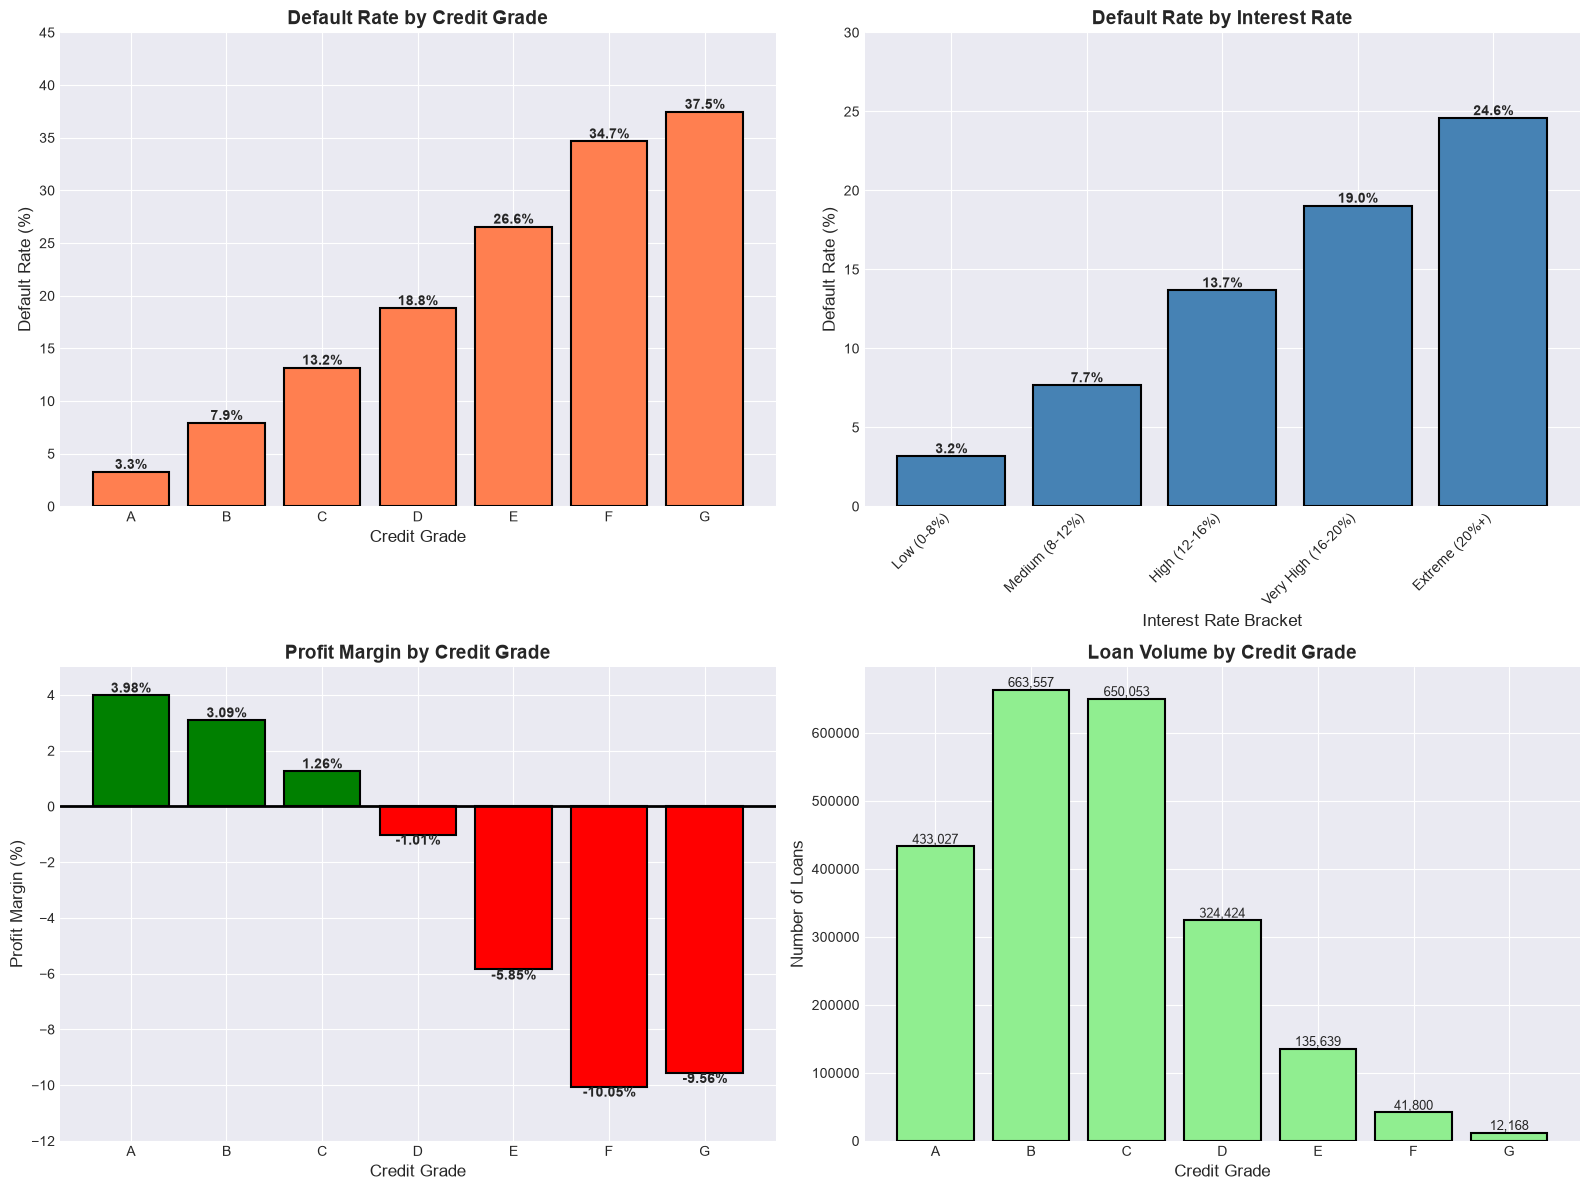

In [21]:
import subprocess
import sys

# Install matplotlib and seaborn
subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib", "seaborn"])

print("✅ matplotlib and seaborn installed successfully!")
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ============ PLOT 1: Default Rate by Credit Grade ============
grade_default = df.groupby('grade')['is_default'].agg(['sum', 'count', 'mean']).reset_index()
grade_default['default_rate_pct'] = grade_default['mean'] * 100

ax1 = axes[0, 0]
bars1 = ax1.bar(grade_default['grade'], grade_default['default_rate_pct'], color='coral', edgecolor='black', linewidth=1.5)
ax1.set_title('Default Rate by Credit Grade', fontsize=14, fontweight='bold')
ax1.set_xlabel('Credit Grade', fontsize=12)
ax1.set_ylabel('Default Rate (%)', fontsize=12)
ax1.set_ylim(0, 45)
for i, bar in enumerate(bars1):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ============ PLOT 2: Default Rate by Interest Rate Bracket ============
int_default = df.groupby('int_rate_bracket', observed=True)['is_default'].agg(['sum', 'count', 'mean']).reset_index()
int_default['default_rate_pct'] = int_default['mean'] * 100

ax2 = axes[0, 1]
bars2 = ax2.bar(range(len(int_default)), int_default['default_rate_pct'], color='steelblue', edgecolor='black', linewidth=1.5)
ax2.set_title('Default Rate by Interest Rate', fontsize=14, fontweight='bold')
ax2.set_xlabel('Interest Rate Bracket', fontsize=12)
ax2.set_ylabel('Default Rate (%)', fontsize=12)
ax2.set_xticks(range(len(int_default)))
ax2.set_xticklabels(int_default['int_rate_bracket'], rotation=45, ha='right')
ax2.set_ylim(0, 30)
for i, bar in enumerate(bars2):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ============ PLOT 3: Profit Margin by Grade ============
ax3 = axes[1, 0]
colors = ['green' if x > 0 else 'red' for x in profit_analysis['Profit_Margin_Pct']]
bars3 = ax3.bar(profit_analysis.index, profit_analysis['Profit_Margin_Pct'], color=colors, edgecolor='black', linewidth=1.5)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=2)
ax3.set_title('Profit Margin by Credit Grade', fontsize=14, fontweight='bold')
ax3.set_xlabel('Credit Grade', fontsize=12)
ax3.set_ylabel('Profit Margin (%)', fontsize=12)
ax3.set_ylim(-12, 5)
for i, bar in enumerate(bars3):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}%', ha='center', va='bottom' if height > 0 else 'top', fontsize=10, fontweight='bold')

# ============ PLOT 4: Loan Volume by Grade ============
grade_volume = df['grade'].value_counts().sort_index()

ax4 = axes[1, 1]
bars4 = ax4.bar(grade_volume.index, grade_volume.values, color='lightgreen', edgecolor='black', linewidth=1.5)
ax4.set_title('Loan Volume by Credit Grade', fontsize=14, fontweight='bold')
ax4.set_xlabel('Credit Grade', fontsize=12)
ax4.set_ylabel('Number of Loans', fontsize=12)
for i, bar in enumerate(bars4):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('lending_club_analysis_dashboard.png', dpi=300, bbox_inches='tight')
print("✅ Dashboard saved as: lending_club_analysis_dashboard.png")
plt.show()